In [1]:
!kaggle datasets download -d brandao/diabetes

Dataset URL: https://www.kaggle.com/datasets/brandao/diabetes
License(s): CC0-1.0
diabetes.zip: Skipping, found more recently modified local copy (use --force to force download)


In [2]:
import zipfile
with zipfile.ZipFile('diabetes.zip') as f:
    f.extractall()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('diabetic_data.csv')

In [4]:
df.sample(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
14901,57679416,6496668,Caucasian,Male,[40-50),?,3,18,4,10,...,No,Steady,No,No,No,No,No,No,Yes,>30
3265,20400054,820035,Caucasian,Female,[70-80),?,1,5,7,5,...,No,No,No,No,No,No,No,No,Yes,<30
41180,127566348,24540075,Caucasian,Female,[80-90),?,1,3,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,<30
15254,58720500,103031532,Caucasian,Female,[70-80),?,1,3,7,6,...,No,Steady,No,No,No,No,No,Ch,Yes,<30
7779,36220050,3523662,Caucasian,Male,[70-80),?,1,5,7,4,...,No,No,No,No,No,No,No,No,No,>30
74412,221600754,84950370,Caucasian,Male,[70-80),?,1,3,7,3,...,No,Steady,No,No,No,No,No,Ch,Yes,>30
57245,163553400,39878343,Caucasian,Female,[20-30),?,2,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,<30
69232,196512894,87839208,Caucasian,Male,[60-70),?,2,1,1,3,...,No,No,No,No,No,No,No,No,Yes,NO
101448,439575524,32673303,Caucasian,Male,[70-80),?,1,1,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,>30
64966,180916128,31660155,AfricanAmerican,Male,[70-80),?,1,3,7,4,...,No,No,No,No,No,No,No,No,No,NO


In [3]:
df.shape

(101766, 50)

In [7]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [5]:
df.drop(columns=['max_glu_serum','A1Cresult','encounter_id','patient_nbr','admission_type_id', 'discharge_disposition_id','admission_source_id', 'payer_code', 'num_lab_procedures',
              'num_procedures', 'num_medications','number_outpatient','number_emergency','number_inpatient'],inplace=True)

In [6]:
df['medical_specialty'].unique()

array(['Pediatrics-Endocrinology', '?', 'InternalMedicine',
       'Family/GeneralPractice', 'Cardiology', 'Surgery-General',
       'Orthopedics', 'Gastroenterology',
       'Surgery-Cardiovascular/Thoracic', 'Nephrology',
       'Orthopedics-Reconstructive', 'Psychiatry', 'Emergency/Trauma',
       'Pulmonology', 'Surgery-Neuro',
       'Obsterics&Gynecology-GynecologicOnco', 'ObstetricsandGynecology',
       'Pediatrics', 'Hematology/Oncology', 'Otolaryngology',
       'Surgery-Colon&Rectal', 'Pediatrics-CriticalCare', 'Endocrinology',
       'Urology', 'Psychiatry-Child/Adolescent', 'Pediatrics-Pulmonology',
       'Neurology', 'Anesthesiology-Pediatric', 'Radiology',
       'Pediatrics-Hematology-Oncology', 'Psychology', 'Podiatry',
       'Gynecology', 'Oncology', 'Pediatrics-Neurology',
       'Surgery-Plastic', 'Surgery-Thoracic',
       'Surgery-PlasticwithinHeadandNeck', 'Ophthalmology',
       'Surgery-Pediatric', 'Pediatrics-EmergencyMedicine',
       'PhysicalMedicineandRe

In [7]:
df=df.replace('?',np.nan)

<Axes: xlabel='race', ylabel='count'>

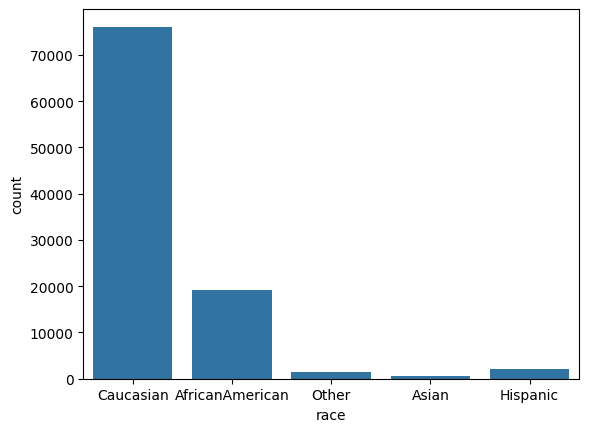

In [8]:
sns.countplot(data=df,x='race')

In [9]:
x=(pd.crosstab(df['race'],df['readmitted']))
x

readmitted,<30,>30,NO
race,,,
AfricanAmerican,2155,6634,10421
Asian,65,161,415
Caucasian,8592,27124,40383
Hispanic,212,642,1183
Other,145,446,915


<Axes: xlabel='readmitted', ylabel='race'>

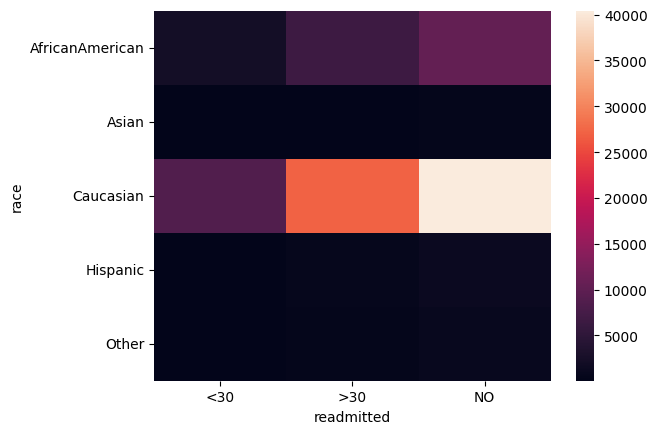

In [10]:
sns.heatmap(x)

In [11]:
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [12]:
df=df[df['gender']!='Unknown/Invalid']   ### dropping unknown/invalid as too small data

In [13]:
df['age']=df['age'].str.strip('[)').str.split('-').apply(lambda x: (int(x[0])+int(x[1]))/2)   ###str.strip() removes leading and trailing characters from each string, not the ones in the middle.

In [14]:
y=pd.crosstab(df['age'],df['readmitted'])

<Axes: xlabel='readmitted', ylabel='age'>

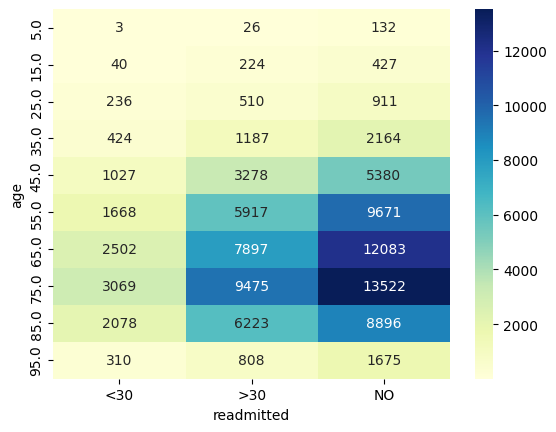

In [19]:
sns.heatmap(y,cmap="YlGnBu",annot=True,fmt="d")

In [20]:
df['age']=df['age'].astype(int)

In [21]:
df['weight'].unique()

array([nan, '[75-100)', '[50-75)', '[0-25)', '[100-125)', '[25-50)',
       '[125-150)', '[175-200)', '[150-175)', '>200'], dtype=object)

In [22]:
df['time_in_hospital'].unique()

array([ 1,  3,  2,  4,  5, 13, 12,  9,  7, 10,  6, 11,  8, 14])

<Axes: xlabel='time_in_hospital', ylabel='readmitted'>

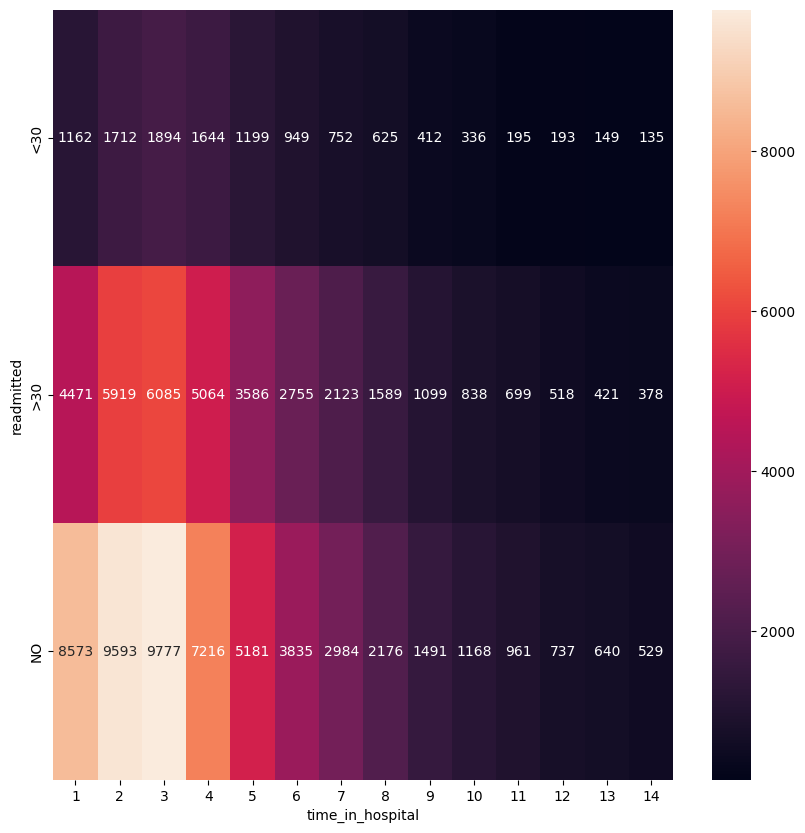

In [31]:
plt.figure(figsize=(10,10))
sns.heatmap(pd.crosstab(df['readmitted'],df['time_in_hospital']),annot=True,fmt='d')

In [24]:
df['medical_specialty'].value_counts()

medical_specialty
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5351
Surgery-General            3099
                          ...  
Proctology                    1
Speech                        1
SportsMedicine                1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 72, dtype: int64

In [25]:
df['diag_3'].value_counts()

diag_3
250    11555
401     8288
276     5175
428     4577
427     3955
       ...  
14         1
750        1
370        1
671        1
971        1
Name: count, Length: 789, dtype: int64

In [26]:
# sns.scatterplot(data=df,x='diag_1',y='diag_2',hue='readmitted')

In [27]:
df['number_diagnoses'].value_counts()

number_diagnoses
9     49473
5     11392
8     10616
7     10393
6     10161
4      5536
3      2835
2      1023
1       219
16       45
10       17
13       16
11       11
15       10
12        9
14        7
Name: count, dtype: int64

In [47]:
insulin=df['insulin']

In [48]:
for i in df.iloc[:,10:-3].columns:
    print(f"columns: {i} {df[i].unique()}")

columns: metformin ['No' 'Steady' 'Up' 'Down']
columns: repaglinide ['No' 'Up' 'Steady' 'Down']
columns: nateglinide ['No' 'Steady' 'Down' 'Up']
columns: chlorpropamide ['No' 'Steady' 'Down' 'Up']
columns: glimepiride ['No' 'Steady' 'Down' 'Up']
columns: acetohexamide ['No' 'Steady']
columns: glipizide ['No' 'Steady' 'Up' 'Down']
columns: glyburide ['No' 'Steady' 'Up' 'Down']
columns: tolbutamide ['No' 'Steady']
columns: pioglitazone ['No' 'Steady' 'Up' 'Down']
columns: rosiglitazone ['No' 'Steady' 'Up' 'Down']
columns: acarbose ['No' 'Steady' 'Up' 'Down']
columns: miglitol ['No' 'Steady' 'Down' 'Up']
columns: troglitazone ['No' 'Steady']
columns: tolazamide ['No' 'Steady' 'Up']
columns: examide ['No']
columns: citoglipton ['No']
columns: insulin ['No' 'Up' 'Steady' 'Down']
columns: glyburide-metformin ['No' 'Steady' 'Down' 'Up']
columns: glipizide-metformin ['No' 'Steady']
columns: glimepiride-pioglitazone ['No' 'Steady']
columns: metformin-rosiglitazone ['No' 'Steady']
columns: metfo

In [49]:
df['change'].unique()

array(['No', 'Ch'], dtype=object)

In [50]:
df['diabetesMed'].unique()

array(['No', 'Yes'], dtype=object)

In [51]:
from sklearn.compose import ColumnTransformer

In [52]:
df.loc[df['weight']=='>200','weight']=200

In [53]:
df.loc[(df['weight'].notnull())&( df['weight']!=200),'weight']=df.loc[(df['weight'].notnull())&( df['weight']!=200),'weight'].str.strip('[)').str.split('-').apply(lambda x: int(x[0])+int(x[1])/2)

In [54]:
df['weight']=df['weight'].astype(float)

In [55]:
df['diag_3'].fillna(df['diag_3'].mode()[0],inplace=True)
df['diag_2'].fillna(df['diag_2'].mode()[0],inplace=True)
df['diag_1'].fillna(df['diag_1'].mode()[0],inplace=True)

C:\Users\This pc\AppData\Local\Temp\ipykernel_20712\3025226975.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['diag_3'].fillna(df['diag_3'].mode()[0],inplace=True)
C:\Users\This pc\AppData\Local\Temp\ipykernel_20712\3025226975.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [56]:
df.loc[df ['diag_3'].str.startswith('V'),'diag_3']=df[df ['diag_3'].str.startswith('V')]['diag_3'].str[1:]
df.loc[df ['diag_3'].str.startswith('E'),'diag_3']=df[df ['diag_3'].str.startswith('E')]['diag_3'].str[1:]
df.loc[df ['diag_2'].str.startswith('V'),'diag_2']=df[df ['diag_2'].str.startswith('V')]['diag_2'].str[1:]
df.loc[df ['diag_2'].str.startswith('E'),'diag_2']=df[df ['diag_2'].str.startswith('E')]['diag_2'].str[1:]
df.loc[df ['diag_1'].str.startswith('V'),'diag_1']=df[df ['diag_1'].str.startswith('V')]['diag_1'].str[1:]
df.loc[df ['diag_1'].str.startswith('E'),'diag_1']=df[df ['diag_1'].str.startswith('E')]['diag_1'].str[1:]

In [57]:
df['diag_1']=df['diag_1'].astype(float)
df['diag_2']=df['diag_2'].astype(float)
df['diag_3']=df['diag_3'].astype(float)

In [58]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['readmitted']),df['readmitted'],test_size=0.2,random_state=42)

In [59]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder,OneHotEncoder

In [60]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer

In [61]:
df['readmitted']

0          NO
1         >30
2          NO
3          NO
4          NO
         ... 
101761    >30
101762     NO
101763     NO
101764     NO
101765     NO
Name: readmitted, Length: 101763, dtype: object

In [62]:
def map_medications(X): 
    med_mapping = {'No':0, 'Steady':1, 'Up':2, 'Down':-1} # FunctionTransformer to apply mapping 
    return X.replace(med_mapping)
med_transformer = FunctionTransformer(map_medications)

In [63]:
col_trans=ColumnTransformer(
    transformers=[
        ('tnf1',med_transformer,['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide','glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone',
                'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin','metformin-pioglitazone','metformin-rosiglitazone','glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone']),
        ('tnf2',OneHotEncoder(handle_unknown='ignore',sparse_output=False,drop='first'),['gender','change','diabetesMed']),
        ('tnf3',KNNImputer(),['weight'])
    ],
    remainder='passthrough'
).set_output(transform='pandas')

In [64]:
df[['gender','change','diabetesMed']]

,gender,change,diabetesMed
0,Female,No,No
1,Female,Ch,Yes
2,Female,No,Yes
3,Male,Ch,Yes
4,Male,Ch,Yes
...,...,...,...
101761,Male,Ch,Yes
101762,Female,No,Yes
101763,Male,Ch,Yes
101764,Female,Ch,Yes


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101763 entries, 0 to 101765
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   race                      99492 non-null   object 
 1   gender                    101763 non-null  object 
 2   age                       101763 non-null  int64  
 3   weight                    3197 non-null    float64
 4   time_in_hospital          101763 non-null  int64  
 5   medical_specialty         51816 non-null   object 
 6   diag_1                    101763 non-null  float64
 7   diag_2                    101763 non-null  float64
 8   diag_3                    101763 non-null  float64
 9   number_diagnoses          101763 non-null  int64  
 10  metformin                 101763 non-null  object 
 11  repaglinide               101763 non-null  object 
 12  nateglinide               101763 non-null  object 
 13  chlorpropamide            101763 non-null  object

In [66]:
race_pipeline=Pipeline([
     ('impute',SimpleImputer(strategy='most_frequent')),
     ('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first'))
    ])

In [67]:
col_transformer=ColumnTransformer(
    transformers=[
        ('columns_trans',col_trans,['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide','glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone',
                'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin','gender','change','diabetesMed','weight','metformin-pioglitazone','metformin-rosiglitazone','glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone']),
        ('race',race_pipeline,['race'])
    ],
    remainder='passthrough'
).set_output(transform='pandas')

In [68]:
df['diabetesMed'].unique()

array(['No', 'Yes'], dtype=object)

In [69]:
X_train=col_transformer.fit_transform(X_train)

C:\Users\This pc\AppData\Local\Temp\ipykernel_20712\3200054025.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(med_mapping)


In [70]:
X_test=col_transformer.fit_transform(X_test)

C:\Users\This pc\AppData\Local\Temp\ipykernel_20712\3200054025.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(med_mapping)


In [71]:
df['metformin-rosiglitazone'].value_counts()

metformin-rosiglitazone
No        101761
Steady         2
Name: count, dtype: int64

In [107]:
lenc=LabelEncoder()
y_train=lenc.fit_transform(y_train)
y_test=lenc.transform(y_test)

In [75]:
from sklearn.decomposition import PCA

In [76]:
to_pCA=[]
for i in range(23):
    to_pCA.append(X_train.columns[i])

In [77]:
to_pCA

['columns_trans__tnf1__metformin',
 'columns_trans__tnf1__repaglinide',
 'columns_trans__tnf1__nateglinide',
 'columns_trans__tnf1__chlorpropamide',
 'columns_trans__tnf1__glimepiride',
 'columns_trans__tnf1__acetohexamide',
 'columns_trans__tnf1__glipizide',
 'columns_trans__tnf1__glyburide',
 'columns_trans__tnf1__tolbutamide',
 'columns_trans__tnf1__pioglitazone',
 'columns_trans__tnf1__rosiglitazone',
 'columns_trans__tnf1__acarbose',
 'columns_trans__tnf1__miglitol',
 'columns_trans__tnf1__troglitazone',
 'columns_trans__tnf1__tolazamide',
 'columns_trans__tnf1__examide',
 'columns_trans__tnf1__citoglipton',
 'columns_trans__tnf1__insulin',
 'columns_trans__tnf1__metformin-pioglitazone',
 'columns_trans__tnf1__metformin-rosiglitazone',
 'columns_trans__tnf1__glyburide-metformin',
 'columns_trans__tnf1__glipizide-metformin',
 'columns_trans__tnf1__glimepiride-pioglitazone']

In [78]:
without_pca=X_train.drop(columns=to_pCA)

In [79]:
from sklearn.decomposition import PCA

In [80]:
pca=PCA(svd_solver='auto',random_state=42).set_output(transform='pandas')

In [81]:
pca_cols=pca.fit_transform(X_train[to_pCA])

In [82]:
without_pca_test=X_test.drop(columns=to_pCA)

In [83]:
pca.explained_variance_     ###Eigen values ( tells how much of the total variance these eigen vectors can explain)

array([7.04808350e-01, 1.96521069e-01, 1.38057718e-01, 1.09221659e-01,
       7.47046820e-02, 6.30598524e-02, 5.54799693e-02, 1.79509214e-02,
       7.78868804e-03, 7.21368131e-03, 3.30011591e-03, 9.93929910e-04,
       4.41868269e-04, 4.29669232e-04, 2.57857786e-04, 1.35018172e-04,
       3.68452354e-05, 1.22836541e-05, 1.22831395e-05, 1.22829666e-05,
       1.22802386e-05, 0.00000000e+00, 0.00000000e+00])

In [84]:
pca.components_   ###Eigen vectors

array([[ 2.22284173e-04, -7.24170489e-04, -1.86595490e-04,
        -2.99371331e-04,  4.17413396e-03,  1.03187670e-05,
         1.83396235e-03, -8.66966347e-03, -2.74556192e-05,
        -3.57139416e-04,  1.88872358e-03, -2.09868341e-05,
        -1.18175968e-04, -2.12221402e-05, -7.75600876e-05,
         1.79366203e-43, -0.00000000e+00,  9.99949806e-01,
         1.03086684e-05, -2.45368123e-05,  1.41580591e-04,
         8.81845912e-06,  1.03187670e-05],
       [ 9.65409319e-01,  1.14266853e-04,  2.96914670e-03,
        -8.44469298e-04,  2.09594269e-02, -1.46687997e-05,
         1.37124980e-01,  2.01326842e-01, -2.96773734e-04,
         5.50228747e-02,  7.17148490e-02,  2.79669282e-03,
         2.63701180e-04, -3.84202020e-05,  3.41506362e-04,
        -0.00000000e+00, -0.00000000e+00,  1.07725947e-03,
        -7.15765465e-05, -1.48034775e-05, -4.52155542e-03,
        -7.39898330e-05, -1.46687997e-05],
       [-3.33816793e-02, -4.72280939e-04, -6.56740095e-04,
        -3.39472594e-04, -3.2

In [85]:
np.cumsum(pca.explained_variance_ratio_)       ##pca.explained_variance_ratio_  gives importance of each eigen value np.cumsum() is used to cummulative sum

array([0.51056382, 0.65292387, 0.752933  , 0.83205327, 0.88616942,
       0.93185003, 0.97203977, 0.98504344, 0.99068557, 0.99591117,
       0.99830177, 0.99902178, 0.99934187, 0.99965312, 0.99983991,
       0.99993772, 0.99996441, 0.99997331, 0.99998221, 0.9999911 ,
       1.        , 1.        , 1.        ])

In [64]:
X_train[to_pCA].shape

(81410, 23)

In [86]:
pca_learn=PCA(n_components=6,random_state=42).set_output(transform='pandas')

In [87]:
X_learn_train=pca_learn.fit_transform(X_train[to_pCA])
X_learn_test=pca_learn.fit_transform(X_test[to_pCA])

In [88]:
pca_Xtrain=pd.concat([without_pca,X_learn_train],axis=1)
pca_Xtest=pd.concat([without_pca_test,X_learn_test],axis=1)

In [89]:
pca_Xtrain.drop('remainder__medical_specialty',axis=1,inplace=True)
pca_Xtest.drop('remainder__medical_specialty',axis=1,inplace=True)

In [90]:
pca_Xtest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20353 entries, 35957 to 91216
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   columns_trans__tnf2__gender_Male      20353 non-null  float64
 1   columns_trans__tnf2__change_No        20353 non-null  float64
 2   columns_trans__tnf2__diabetesMed_Yes  20353 non-null  float64
 3   columns_trans__tnf3__weight           20353 non-null  float64
 4   race__race_Asian                      20353 non-null  float64
 5   race__race_Caucasian                  20353 non-null  float64
 6   race__race_Hispanic                   20353 non-null  float64
 7   race__race_Other                      20353 non-null  float64
 8   remainder__age                        20353 non-null  int64  
 9   remainder__time_in_hospital           20353 non-null  int64  
 10  remainder__diag_1                     20353 non-null  float64
 11  remainder__diag_

In [91]:
pca_Xtest['columns_trans__tnf3__weight'].unique()

array([125.05832037, 162.5       , 125.        ,  87.5       ,
       200.        ,  50.        , 237.5       ,  12.5       ,
       275.        ])

<Axes: >

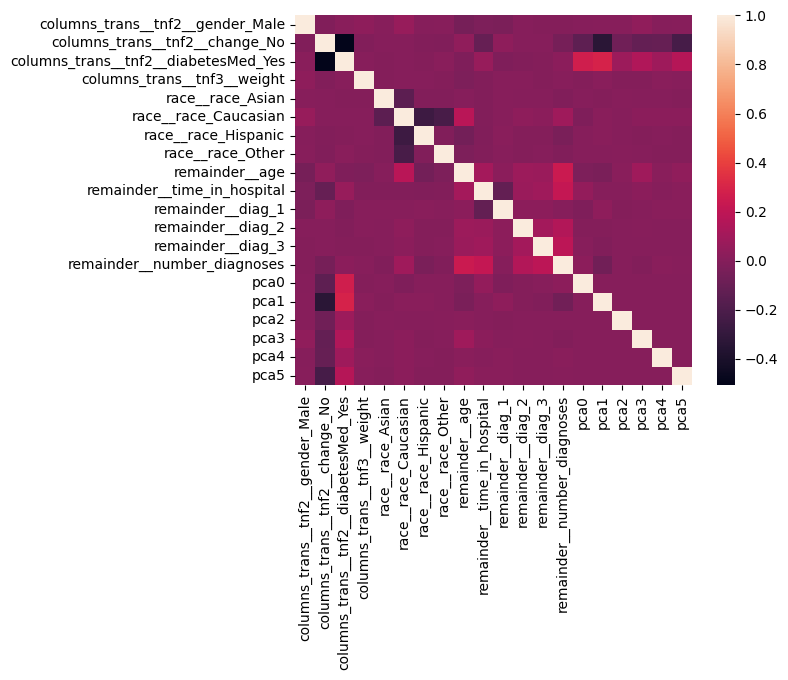

In [92]:
sns.heatmap(pca_Xtrain.corr())

In [93]:
pca_Xtrain.corr()

,columns_trans__tnf2__gender_Male,columns_trans__tnf2__change_No,columns_trans__tnf2__diabetesMed_Yes,columns_trans__tnf3__weight,race__race_Asian,race__race_Caucasian,race__race_Hispanic,race__race_Other,remainder__age,remainder__time_in_hospital,remainder__diag_1,remainder__diag_2,remainder__diag_3,remainder__number_diagnoses,pca0,pca1,pca2,pca3,pca4,pca5
columns_trans__tnf2__gender_Male,1.000000,-0.016591,0.015508,3.095269e-02,0.007578,0.063376,-7.228438e-04,0.008056,-0.053375,-0.027869,-0.034806,0.000926,-0.001328,-0.003853,7.475039e-04,9.013563e-03,1.084736e-02,3.682684e-02,2.188770e-03,8.442375e-03
columns_trans__tnf2__change_No,-0.016591,1.000000,-0.507271,-7.960138e-03,0.000722,0.001394,-8.460048e-03,-0.018505,0.037162,-0.110050,0.029825,0.003682,0.000064,-0.052574,-1.414745e-01,-3.370891e-01,-7.618451e-02,-1.185068e-01,-1.108950e-01,-2.247066e-01
columns_trans__tnf2__diabetesMed_Yes,0.015508,-0.507271,1.000000,6.868380e-03,-0.003053,-0.000895,-1.501980e-03,0.012704,-0.023446,0.063016,-0.023854,-0.009391,-0.005088,0.022101,2.657039e-01,2.908180e-01,7.973782e-02,1.501134e-01,8.384299e-02,1.698233e-01
columns_trans__tnf3__weight,0.030953,-0.007960,0.006868,1.000000e+00,-0.006276,0.002705,3.835039e-16,-0.004104,-0.025025,-0.008814,0.010716,0.008026,-0.002893,0.010669,-4.050591e-03,1.575123e-02,-3.999486e-03,-1.656444e-03,1.129038e-02,1.027676e-02
race__race_Asian,0.007578,0.000722,-0.003053,-6.276020e-03,1.000000,-0.147352,-1.149751e-02,-0.009849,0.001287,-0.011258,0.007237,0.001825,0.004430,-0.013773,3.814927e-04,-1.782893e-03,5.675513e-03,4.553140e-03,5.054421e-04,-1.583825e-03
race__race_Caucasian,0.063376,0.001394,-0.000895,2.704578e-03,-0.147352,1.000000,-2.615181e-01,-0.224020,0.176541,-0.007336,0.007364,0.030035,0.017127,0.091736,-1.999434e-02,1.299798e-02,1.190533e-03,1.985261e-02,1.866885e-02,2.252987e-02
race__race_Hispanic,-0.000723,-0.008460,-0.001502,3.835039e-16,-0.011498,-0.261518,1.000000e+00,-0.017480,-0.063655,-0.014637,0.013914,-0.003016,-0.006671,-0.036536,1.826813e-03,1.138743e-02,4.928598e-03,-5.467128e-03,1.244987e-03,-5.378085e-03
race__race_Other,0.008056,-0.018505,0.012704,-4.104061e-03,-0.009849,-0.224020,-1.747973e-02,1.000000,-0.027275,-0.007243,0.006426,-0.005147,0.000830,-0.015945,1.556336e-03,-2.399218e-04,8.153196e-03,2.326375e-03,-1.057357e-03,-3.288896e-03
remainder__age,-0.053375,0.037162,-0.023446,-2.502515e-02,0.001287,0.176541,-6.365522e-02,-0.027275,1.000000,0.109041,0.020935,0.081205,0.071499,0.242294,-2.660352e-02,-3.707252e-02,1.527414e-02,9.152317e-02,1.366861e-02,3.472571e-02
remainder__time_in_hospital,-0.027869,-0.110050,0.063016,-8.814349e-03,-0.011258,-0.007336,-1.463676e-02,-0.007243,0.109041,1.000000,-0.121093,0.072222,0.092768,0.220253,4.882987e-02,2.183049e-03,2.735327e-03,2.260414e-02,1.223105e-03,1.438017e-02


In [94]:
from sklearn.tree import DecisionTreeClassifier

In [95]:
model=DecisionTreeClassifier(max_depth=6,random_state=42)

In [96]:
model.fit(pca_Xtrain,y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [97]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [98]:
y_train_pred=model.predict(pca_Xtrain)

In [99]:
accuracy_score(y_train,y_train_pred)

0.5432747819678172

In [100]:
y_pred=model.predict(pca_Xtest)

In [101]:
score=confusion_matrix(y_test,y_pred)

In [102]:
accuracy_score(y_test,y_pred)

0.45757382204097674

In [103]:
from sklearn.svm import SVC

In [83]:
svm=SVC()

In [114]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

In [136]:
x=np.linspace(0,5,10)
l=[]
r2=[]
for i in x:
    model=Lasso(alpha=i)
    model.fit(pca_Xtrain,y_train)
    l.append(model.coef_.tolist())
    y_pred=model.predict(pca_Xtest)
    r2.append(r2_score(y_test,y_pred))

D:\Environments\myenv\lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
D:\Environments\myenv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
D:\Environments\myenv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.871e+04, tolerance: 3.809e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

C:\Users\This pc\AppData\Local\Temp\ipykernel_20712\419589099.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pca_Xtrain.columns,rotation=45)
C:\Users\This pc\AppData\Local\Temp\ipykernel_20712\419589099.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pca_Xtrain.columns,rotation=45)
C:\Users\This pc\AppData\Local\Temp\ipykernel_20712\419589099.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pca_Xtrain.columns,rotation=45)
C:\Users\This pc\AppData\Local\Temp\ipykernel_20712\419589099.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pca_Xtrain.columns,rotation=45)
C:\U

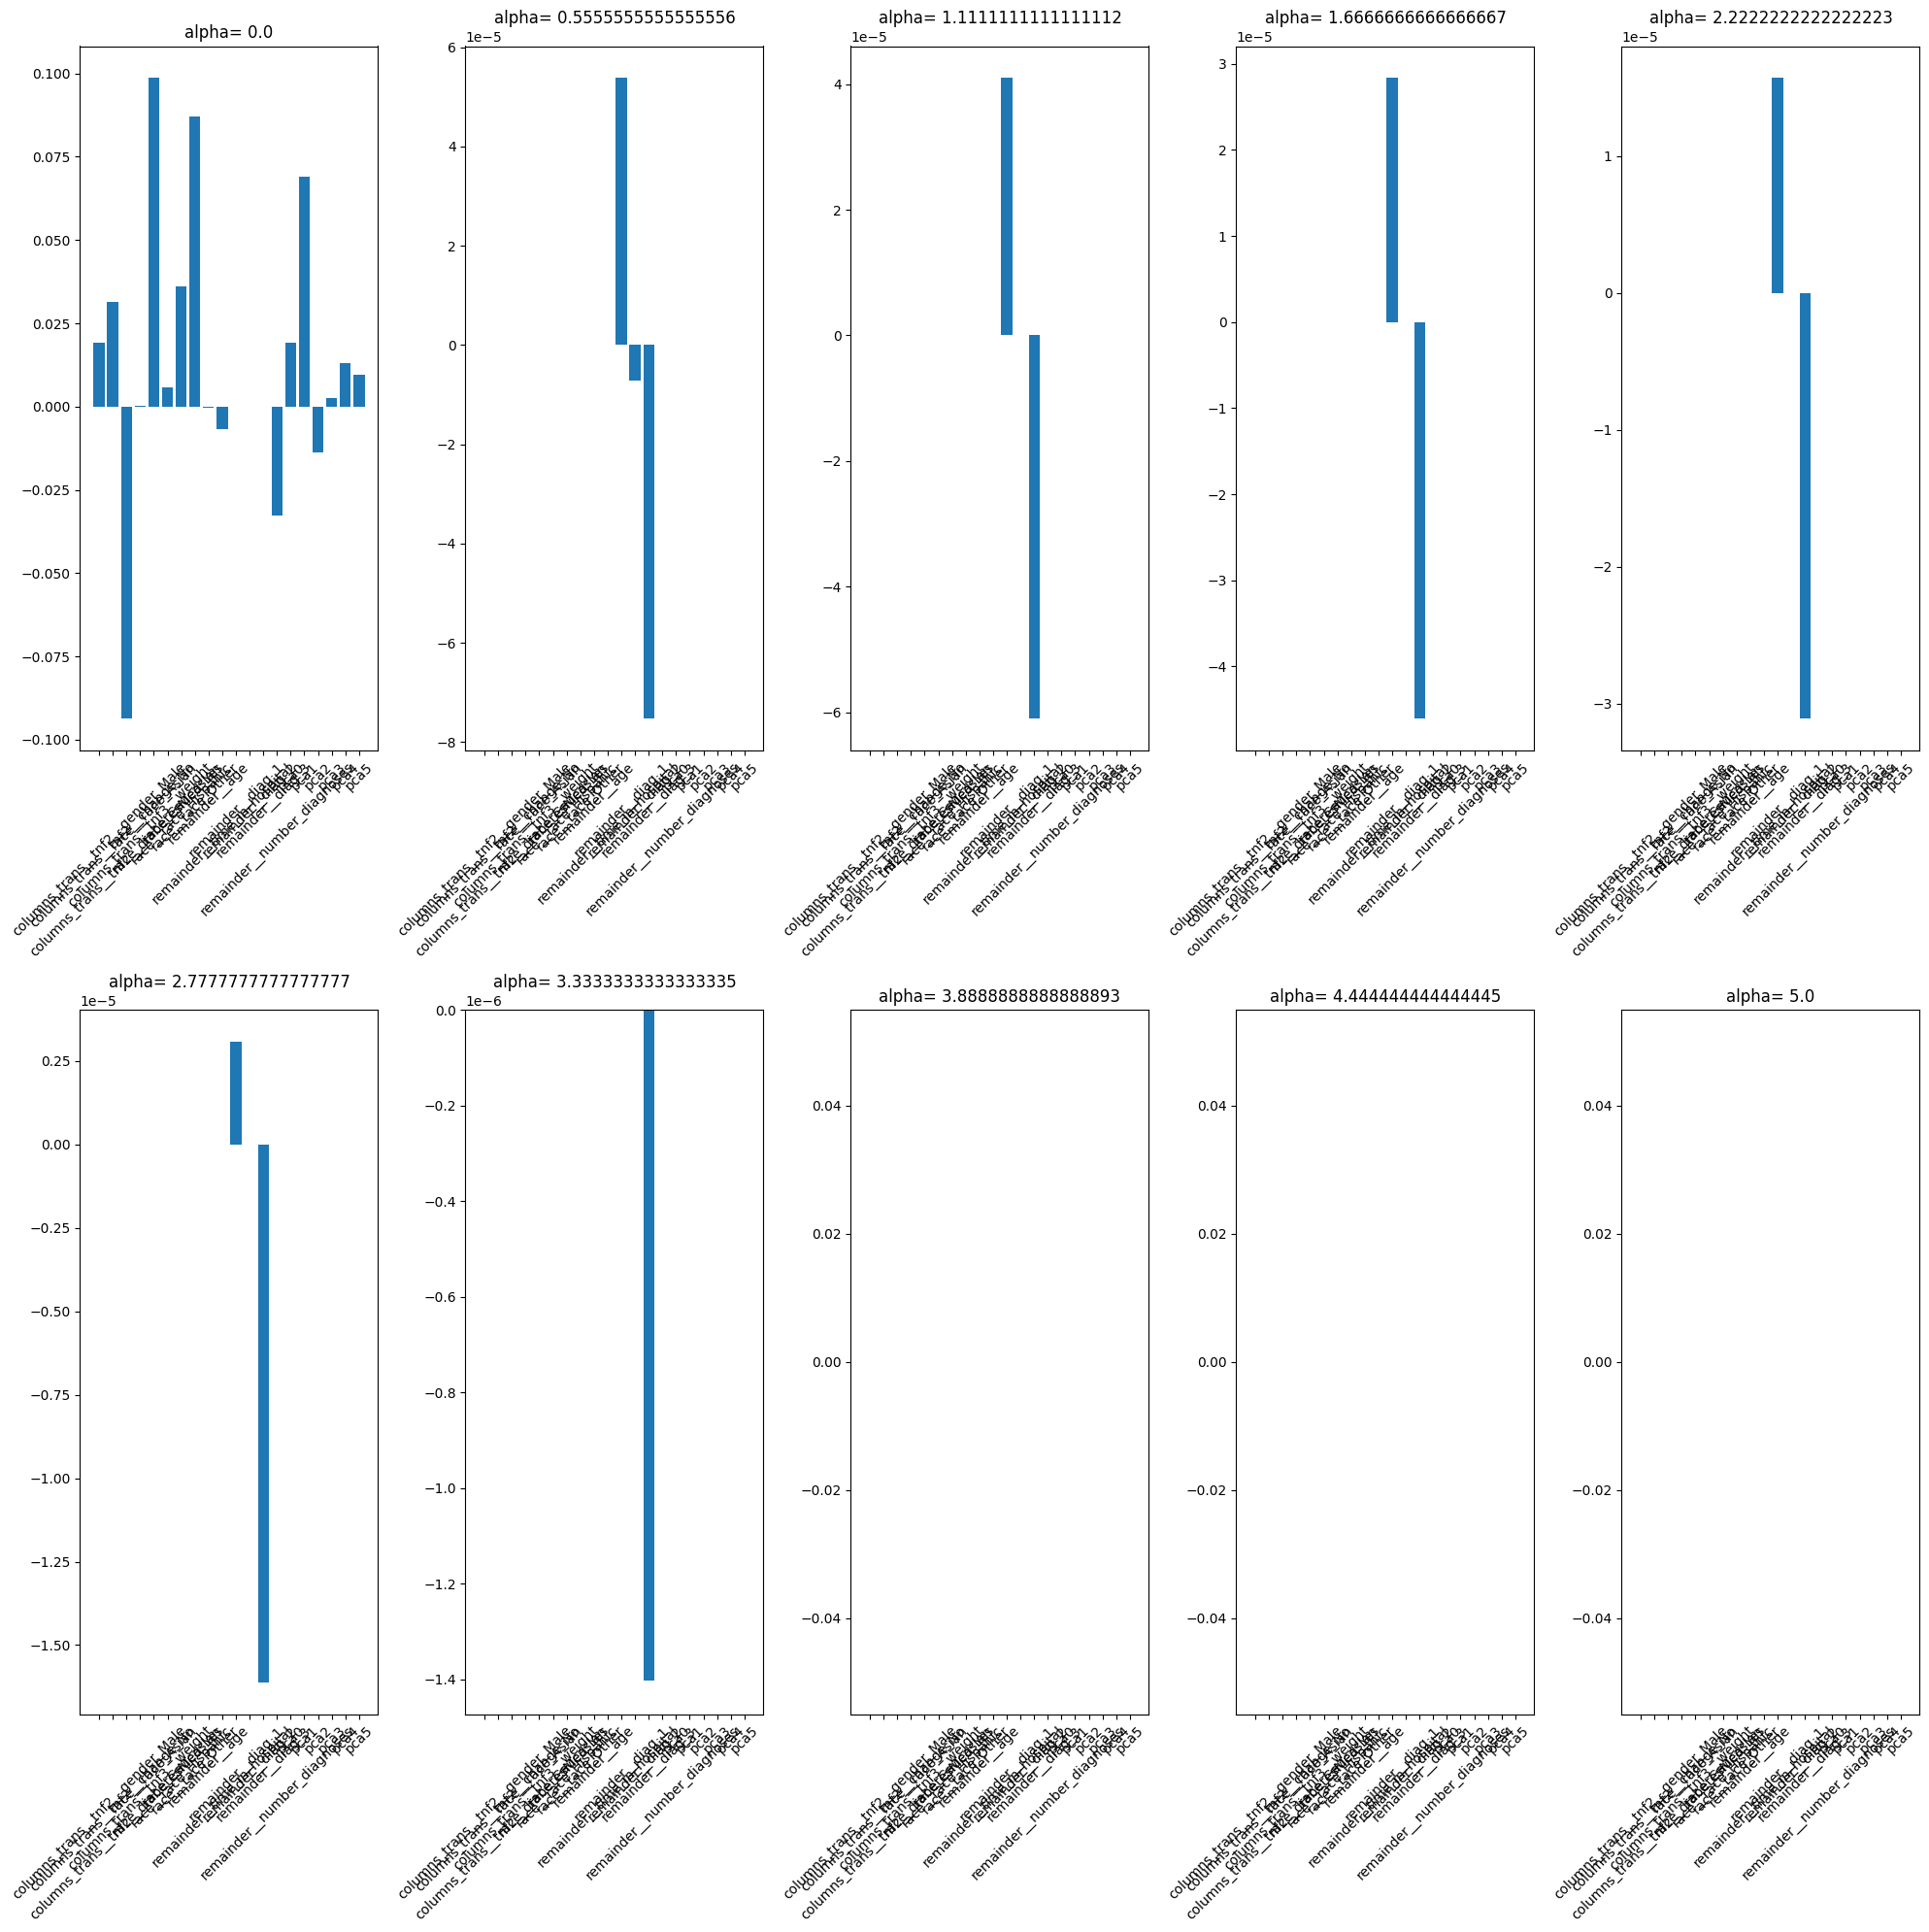

In [137]:
fig,axes=plt.subplots(2,5,figsize=(20,20))
for i,ax in enumerate(axes.flatten()):
    ax.bar(pca_Xtrain.columns,height=l[i])
    ax.set_xticklabels(pca_Xtrain.columns,rotation=45)
    ax.set_title(f'alpha= {x[i]}')
plt.tight_layout()

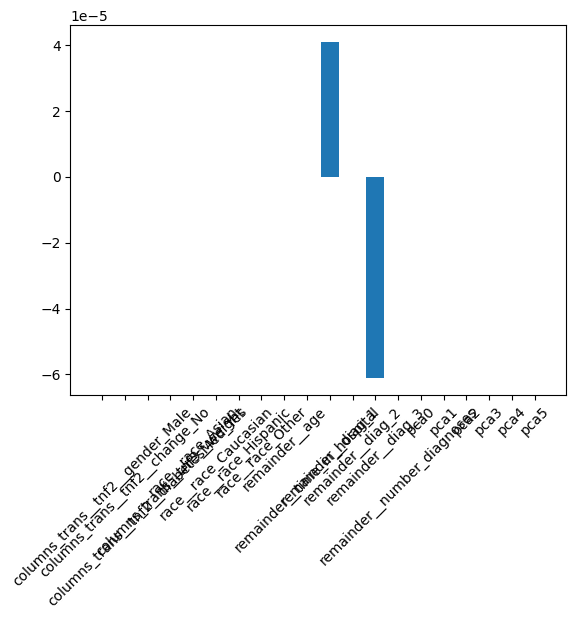

In [142]:
plt.bar(pca_Xtrain.columns,l[2])
plt.xticks(rotation=45);

In [143]:
l[2]

[0.0,
 0.0,
 -0.0,
 0.0,
 0.0,
 -0.0,
 0.0,
 0.0,
 -0.0,
 -0.0,
 4.097140522902215e-05,
 -0.0,
 -6.102857670104426e-05,
 -0.0,
 0.0,
 0.0,
 -0.0,
 -0.0,
 -0.0,
 -0.0]

In [154]:
x_try=pca_Xtrain.iloc[:,10:13:2]

In [162]:
pca_Xtrain[['remainder__diag_1','remainder__diag_3']]

,remainder__diag_1,remainder__diag_3
41511,824.0,401.0
24079,276.0,428.0
91370,250.6,357.0
6237,599.0,599.0
72208,331.0,331.0
...,...,...
6265,786.0,414.0
54887,486.0,401.0
76822,174.0,401.0
860,515.0,599.0


In [157]:
try_mod=DecisionTreeClassifier()

In [159]:
try_mod.fit(x_try,y_train)

DecisionTreeClassifier()

In [166]:
y_try=try_mod.predict(pca_Xtest[['remainder__diag_1','remainder__diag_3']])

In [169]:
from sklearn.svm import SVC

In [170]:
svc=SVC()

In [ ]:
svc.fit(pca_Xtrain,y_train)

In [168]:
accuracy_score(y_test,y_try)

0.4971748636564634